# 📊 Submission Comparison Analysis

เปรียบเทียบ CSV submissions ทั้งหมดกับ **ai_studio_code.csv** (Gold Standard - Score 1.0)

- ตรวจสอบจำนวนคำตอบที่ตรงกัน
- แสดงรายละเอียดคำที่ผิดแต่ละข้อ
- Visualize ผลลัพธ์

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import glob
import os
from IPython.display import display, HTML

# ตั้งค่า matplotlib สำหรับภาษาไทย
matplotlib.rcParams['figure.figsize'] = (14, 8)
matplotlib.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 1. Load Gold Standard & All Submissions

In [2]:
# Load gold standard from the parent root directory
gold = pd.read_csv('../ai_studio_code.csv')
print(f'Gold Standard: {len(gold)} questions')
display(gold.head())

# Find all CSV files in the submissions folder
all_csvs = glob.glob('../submissions/*.csv')
submission_csvs = [
    f for f in all_csvs 
    if not os.path.basename(f).startswith('backup_') 
    and os.path.basename(f) != 'ai_studio_code.csv'
    and os.path.basename(f) != 'advanced_oracle_submission.csv'
]
submission_csvs.sort()

print(f'\n📁 Found {len(submission_csvs)} submission CSV files (excluding backups and excluded files):')
for i, f in enumerate(submission_csvs, 1):
    print(f'  {i}. {os.path.basename(f)}')

Gold Standard: 100 questions


,id,answer
0,1,5
1,2,7
2,3,2
3,4,6
4,5,6



📁 Found 13 submission CSV files (excluding backups and excluded files):
  1. advanced_submission.csv
  2. baai_textsplitter.csv
  3. basic_loop_fast_submission.csv
  4. fast_loop_submission.csv
  5. final_eval_pipeline.csv
  6. improved_advanced_submission.csv
  7. loop_reasoning_submission.csv
  8. pathumma_submission.csv
  9. reflective_submission.csv
  10. sota_contextual_submission.csv
  11. submission_test.csv
  12. typhoon_submission.csv
  13. ultimate_submission_2.csv


## 2. Compare Each Submission with Gold Standard

In [3]:
# Compare each submission
results = []
detailed_errors = {}

for csv_file in submission_csvs:
    try:
        sub = pd.read_csv(csv_file)
        
        # Merge on id
        merged = gold.merge(sub, on='id', suffixes=('_gold', '_sub'))
        
        # Compare
        merged['match'] = merged['answer_gold'] == merged['answer_sub']
        correct = merged['match'].sum()
        total = len(merged)
        accuracy = correct / total * 100 if total > 0 else 0
        
        # Collect errors
        errors = merged[~merged['match']][['id', 'answer_gold', 'answer_sub']].copy()
        errors.columns = ['Question ID', 'Correct Answer', 'Submitted Answer']
        
        results.append({
            'file': os.path.basename(csv_file),
            'full_path': csv_file,
            'total_questions': total,
            'correct': correct,
            'wrong': total - correct,
            'accuracy': accuracy
        })
        
        detailed_errors[os.path.basename(csv_file)] = errors
        
    except Exception as e:
        print(f'❌ Error reading {csv_file}: {e}')
        results.append({
            'file': os.path.basename(csv_file),
            'full_path': csv_file,
            'total_questions': 0,
            'correct': 0,
            'wrong': 0,
            'accuracy': 0
        })

# Create summary DataFrame
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
summary_df.index += 1  # 1-indexed ranking

print('📊 Summary Table (sorted by accuracy):\n')
display(summary_df[['file', 'total_questions', 'correct', 'wrong', 'accuracy']].style
    .format({'accuracy': '{:.1f}%'})
    .bar(subset=['accuracy'], color='#4CAF50', vmin=0, vmax=100)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

📊 Summary Table (sorted by accuracy):



,file,total_questions,correct,wrong,accuracy
1,advanced_submission.csv,100,80,20,80.0%
2,sota_contextual_submission.csv,100,75,25,75.0%
3,ultimate_submission_2.csv,100,74,26,74.0%
4,typhoon_submission.csv,100,72,28,72.0%
5,baai_textsplitter.csv,100,70,30,70.0%
6,improved_advanced_submission.csv,100,69,31,69.0%
7,reflective_submission.csv,100,69,31,69.0%
8,loop_reasoning_submission.csv,100,54,46,54.0%
9,final_eval_pipeline.csv,100,44,56,44.0%
10,basic_loop_fast_submission.csv,100,42,58,42.0%


## 3. Detailed Error Report per Submission

In [4]:
# Show detailed errors for each submission
for csv_file in summary_df['file']:
    errors = detailed_errors.get(csv_file, pd.DataFrame())
    accuracy = summary_df[summary_df['file'] == csv_file]['accuracy'].values[0]
    wrong_count = len(errors)
    
    if wrong_count == 0:
        print(f'\n🎯 {csv_file} — 💯 Perfect Score! (100% accuracy)')
        print('=' * 60)
        continue
    
    print(f'\n📋 {csv_file} — Accuracy: {accuracy:.1f}% ({wrong_count} wrong answers)')
    print('=' * 60)
    
    if not errors.empty:
        display(
            errors.style
            .set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
        )
    print()


📋 advanced_submission.csv — Accuracy: 80.0% (20 wrong answers)


,Question ID,Correct Answer,Submitted Answer
8,9,4,2
9,10,7,2
44,45,3,2
47,48,8,2
59,60,10,9
60,61,10,9
75,76,5,1
78,79,6,5
79,80,7,1
81,82,6,1




📋 sota_contextual_submission.csv — Accuracy: 75.0% (25 wrong answers)


,Question ID,Correct Answer,Submitted Answer
9,10,7,2
12,13,6,3
13,14,4,3
14,15,7,1
47,48,8,2
59,60,10,9
60,61,10,9
61,62,10,9
68,69,2,8
75,76,5,1




📋 ultimate_submission_2.csv — Accuracy: 74.0% (26 wrong answers)


...

,Question ID,Correct Answer,Submitted Answer
3,4,6,9
7,8,4,1
8,9,4,9
9,10,7,2
10,11,4,9
11,12,1,9
12,13,6,9
13,14,4,9
14,15,7,9
15,16,1,9




📋 submission_test.csv — Accuracy: 12.0% (88 wrong answers)


,Question ID,Correct Answer,Submitted Answer
2,3,2,9
8,9,4,2
9,10,7,2
10,11,4,1
12,13,6,1
13,14,4,1
14,15,7,1
16,17,8,1
17,18,5,1
18,19,2,1




📋 pathumma_submission.csv — Accuracy: 7.0% (93 wrong answers)


,Question ID,Correct Answer,Submitted Answer
0,1,5,9
1,2,7,9
2,3,2,9
3,4,6,9
4,5,6,9
5,6,8,9
6,7,1,9
7,8,4,9
8,9,4,9
9,10,7,9


## 4. Visualizations

### 4.1 Accuracy Bar Chart

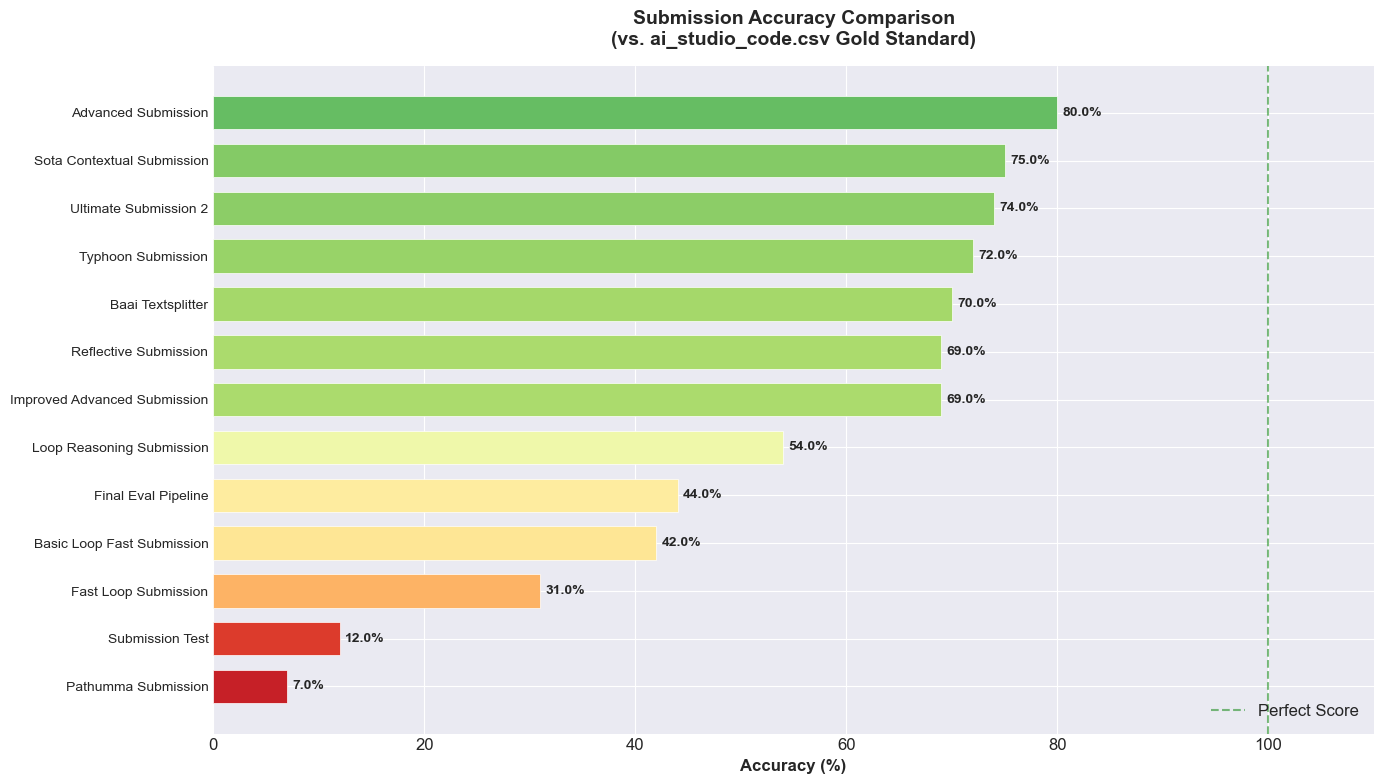

💾 Saved: ../visualizations/accuracy_comparison.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data
plot_df = summary_df.sort_values('accuracy', ascending=True)
files = [f.replace('.csv', '').replace('_', ' ').title() for f in plot_df['file']]
accuracies = plot_df['accuracy'].values

# Color gradient based on accuracy
colors = plt.cm.RdYlGn(accuracies / 100)

bars = ax.barh(range(len(files)), accuracies, color=colors, edgecolor='white', linewidth=0.5, height=0.7)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{acc:.1f}%', va='center', ha='left', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(files)))
ax.set_yticklabels(files, fontsize=10)
ax.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Submission Accuracy Comparison\n(vs. ai_studio_code.csv Gold Standard)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 110)
ax.axvline(x=100, color='green', linestyle='--', alpha=0.5, label='Perfect Score')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../visualizations/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../visualizations/accuracy_comparison.png')

### 4.2 Correct vs Wrong Stacked Bar Chart

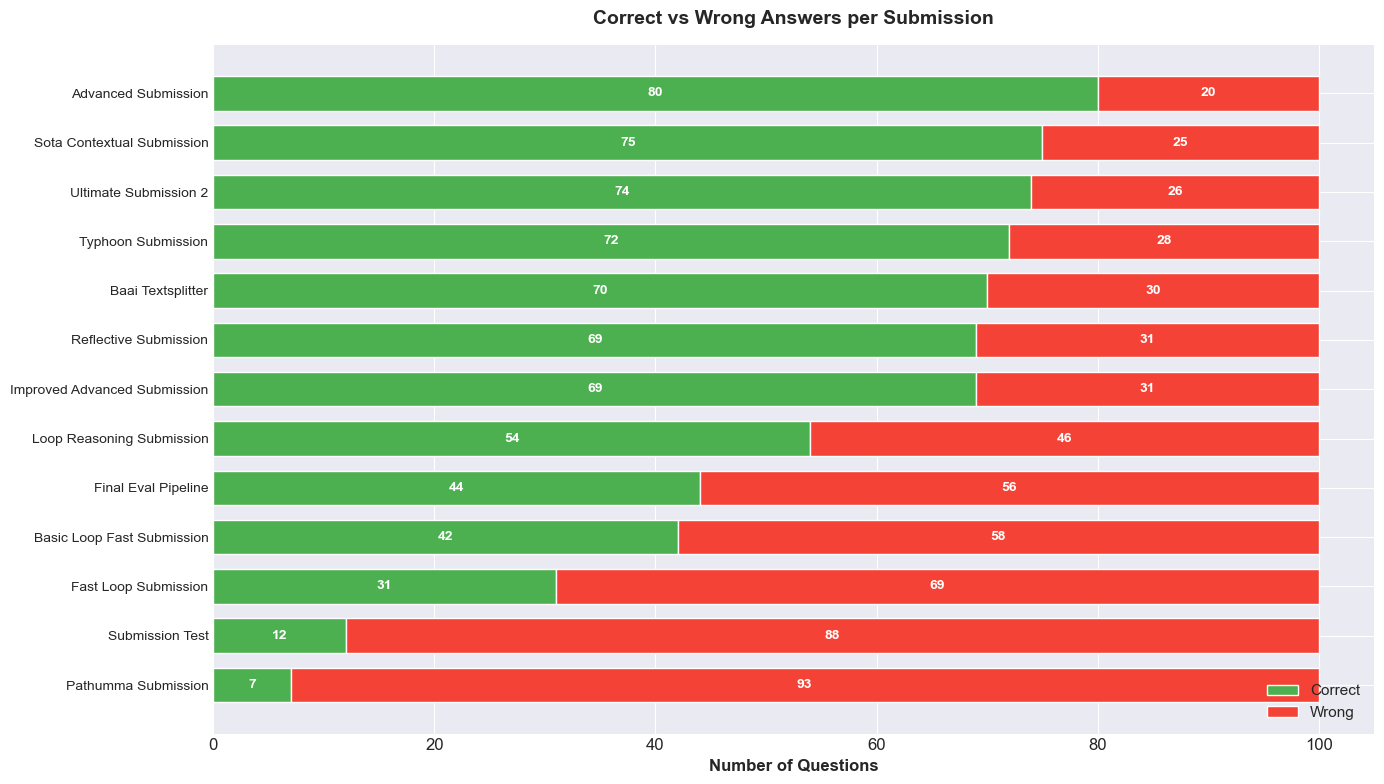

💾 Saved: ../visualizations/correct_vs_wrong.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 8))

plot_df = summary_df.sort_values('accuracy', ascending=True)
files = [f.replace('.csv', '').replace('_', ' ').title() for f in plot_df['file']]
corrects = plot_df['correct'].values
wrongs = plot_df['wrong'].values

y_pos = range(len(files))

bars1 = ax.barh(y_pos, corrects, color='#4CAF50', label='Correct', height=0.7, edgecolor='white')
bars2 = ax.barh(y_pos, wrongs, left=corrects, color='#F44336', label='Wrong', height=0.7, edgecolor='white')

# Add count labels
for i in range(len(files)):
    ax.text(corrects[i]/2, i, str(corrects[i]), va='center', ha='center', 
            fontweight='bold', color='white', fontsize=10)
    if wrongs[i] > 0:
        ax.text(corrects[i] + wrongs[i]/2, i, str(wrongs[i]), va='center', ha='center', 
                fontweight='bold', color='white', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(files, fontsize=10)
ax.set_xlabel('Number of Questions', fontsize=12, fontweight='bold')
ax.set_title('Correct vs Wrong Answers per Submission', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../visualizations/correct_vs_wrong.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../visualizations/correct_vs_wrong.png')

### 4.3 Question-Level Error Heatmap

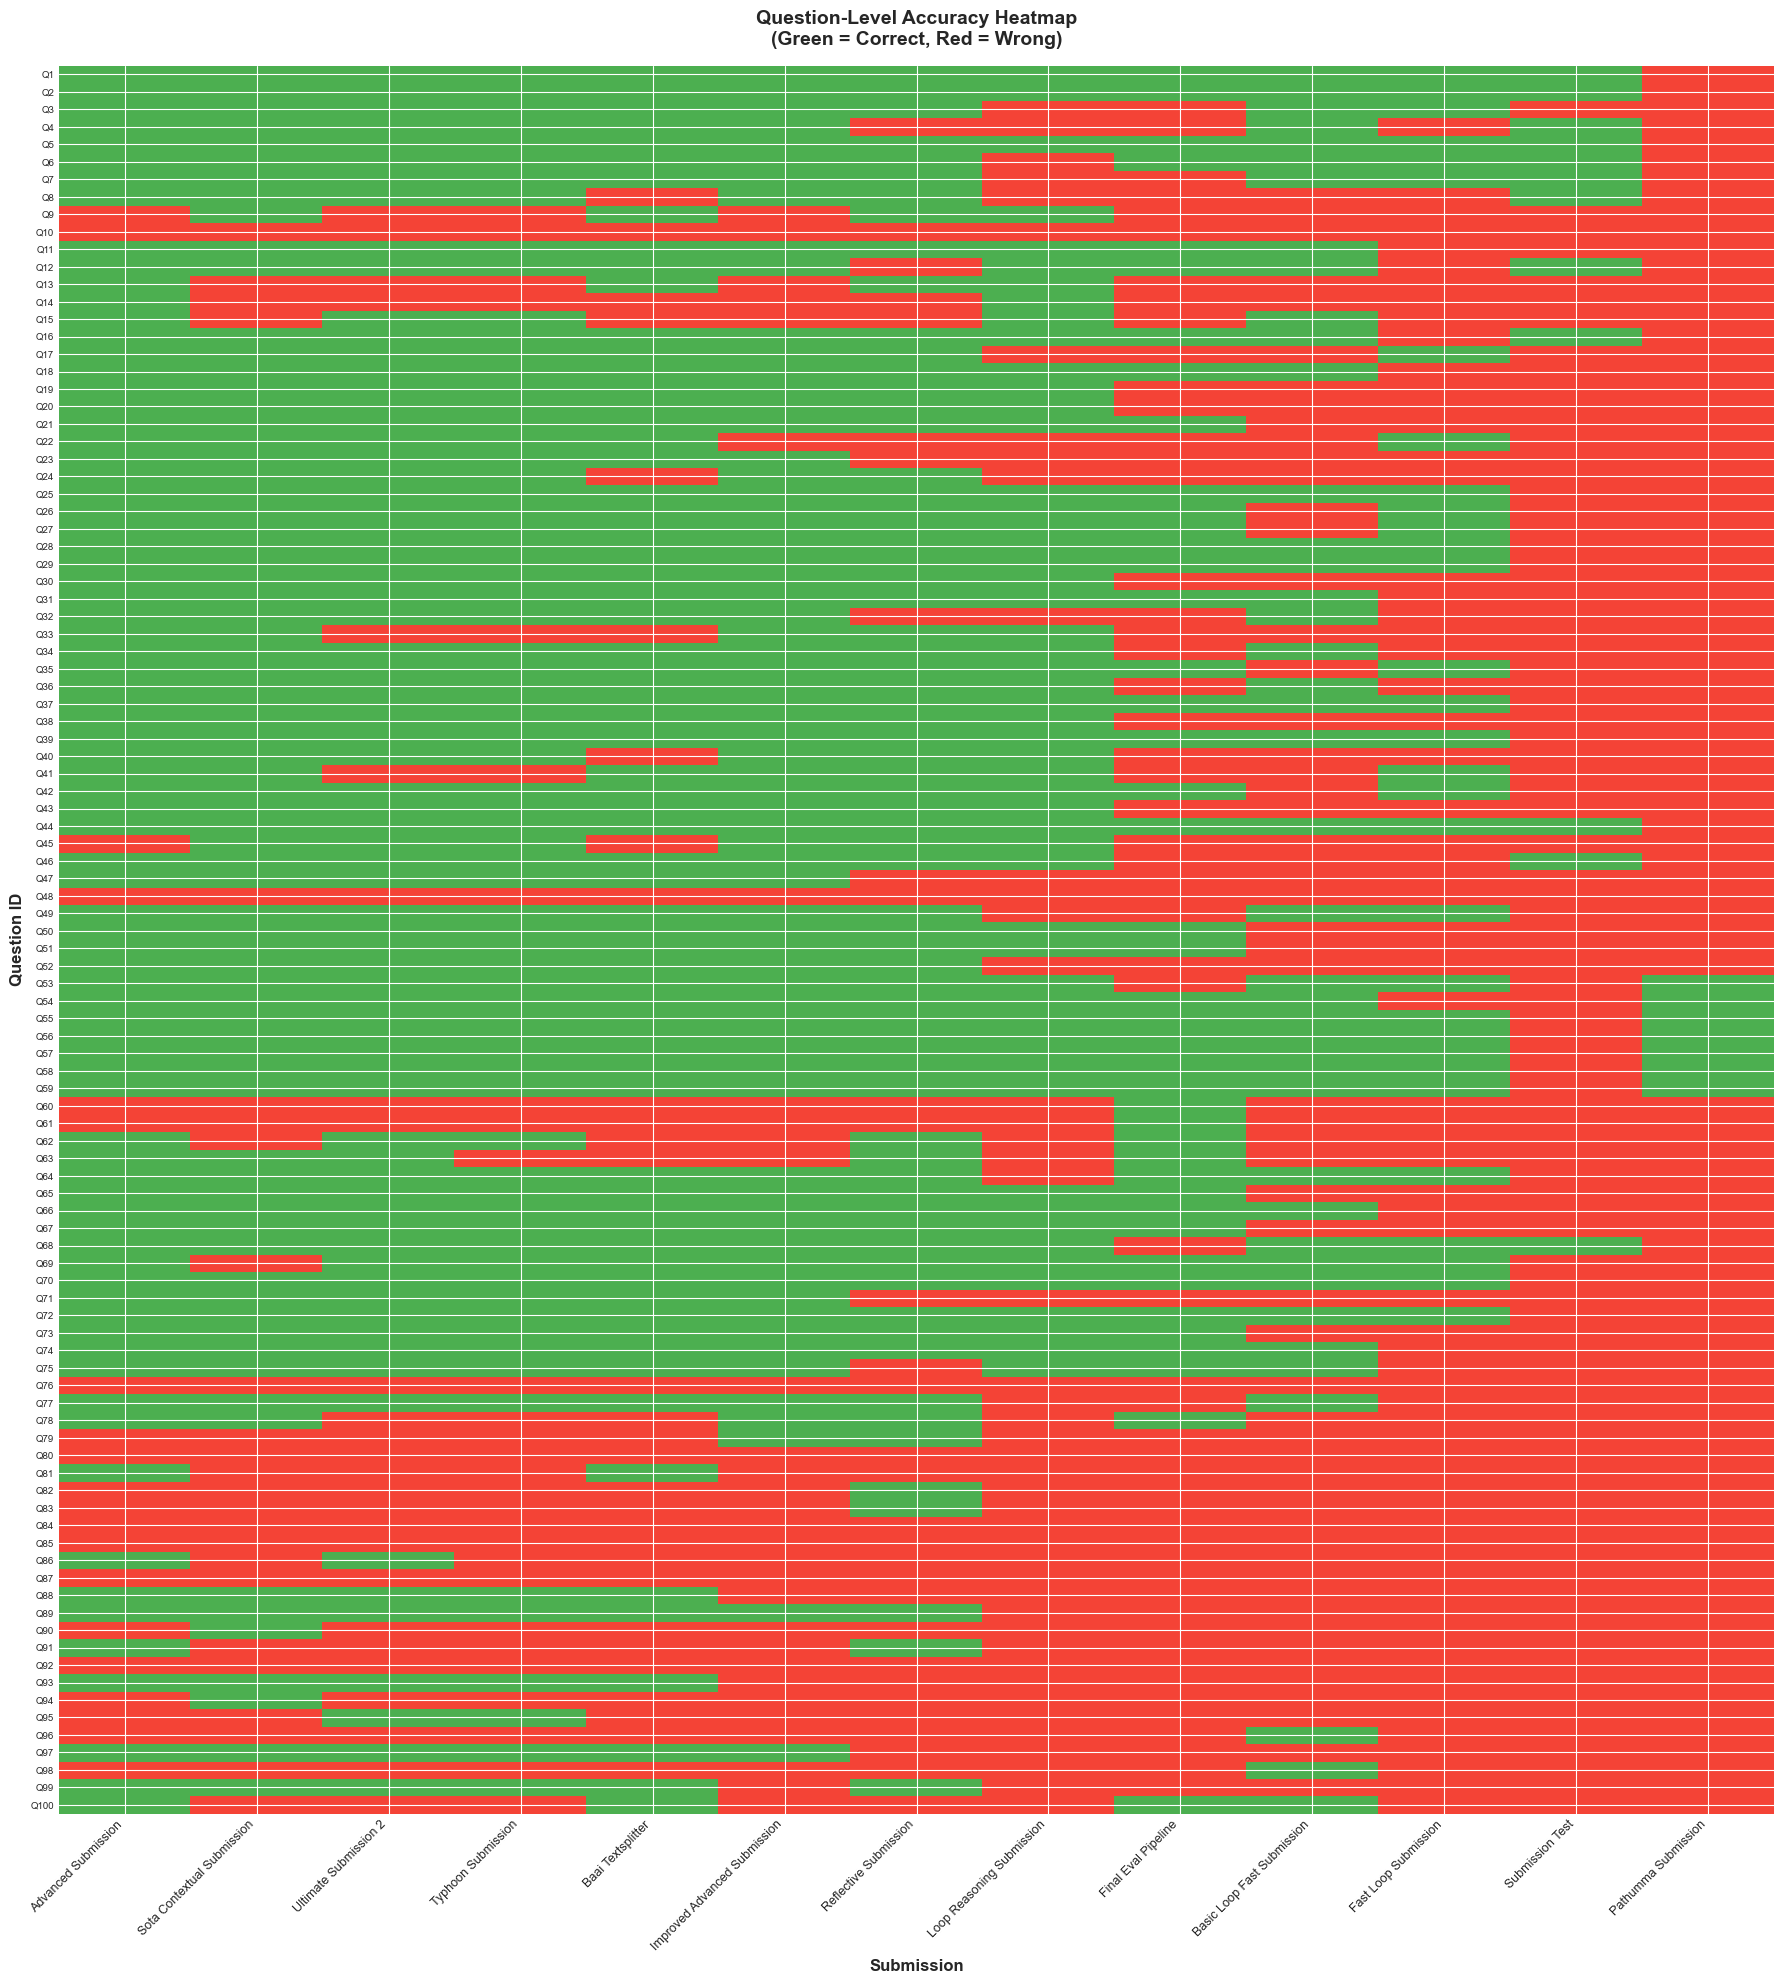

💾 Saved: ../visualizations/error_heatmap.png


In [7]:
# Build a matrix: rows = questions, columns = submissions
question_ids = gold['id'].values
sub_files = summary_df.sort_values('accuracy', ascending=False)['file'].values
sub_paths = summary_df.sort_values('accuracy', ascending=False)['full_path'].values

error_matrix = pd.DataFrame(index=question_ids, columns=sub_files)

for csv_path, csv_name in zip(sub_paths, sub_files):
    try:
        sub = pd.read_csv(csv_path)
        merged = gold.merge(sub, on='id', suffixes=('_gold', '_sub'))
        for _, row in merged.iterrows():
            error_matrix.loc[row['id'], csv_name] = 1 if row['answer_gold'] == row['answer_sub'] else 0
    except:
        pass

error_matrix = error_matrix.astype(float)

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 20))

# Compute display labels
display_cols = [f.replace('.csv', '').replace('_', ' ').title() for f in error_matrix.columns]

cmap = matplotlib.colors.ListedColormap(['#F44336', '#4CAF50'])
im = ax.imshow(error_matrix.values, aspect='auto', cmap=cmap, interpolation='nearest')

ax.set_xticks(range(len(display_cols)))
ax.set_xticklabels(display_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(question_ids)))
ax.set_yticklabels([f'Q{q}' for q in question_ids], fontsize=7)
ax.set_title('Question-Level Accuracy Heatmap\n(Green = Correct, Red = Wrong)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Submission', fontsize=12, fontweight='bold')
ax.set_ylabel('Question ID', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/error_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../visualizations/error_heatmap.png')

### 4.4 Most Frequently Wrong Questions

📌 100 questions were answered incorrectly by at least 1 submission



,Question ID,Times Wrong,Total Submissions,Correct Answer,Wrong Rate
0,87,13,13,7,100.0%
1,80,13,13,7,100.0%
2,10,13,13,7,100.0%
3,84,13,13,5,100.0%
4,76,13,13,5,100.0%
5,85,13,13,4,100.0%
6,48,13,13,8,100.0%
7,92,13,13,4,100.0%
8,90,12,13,5,92.3%
9,94,12,13,4,92.3%


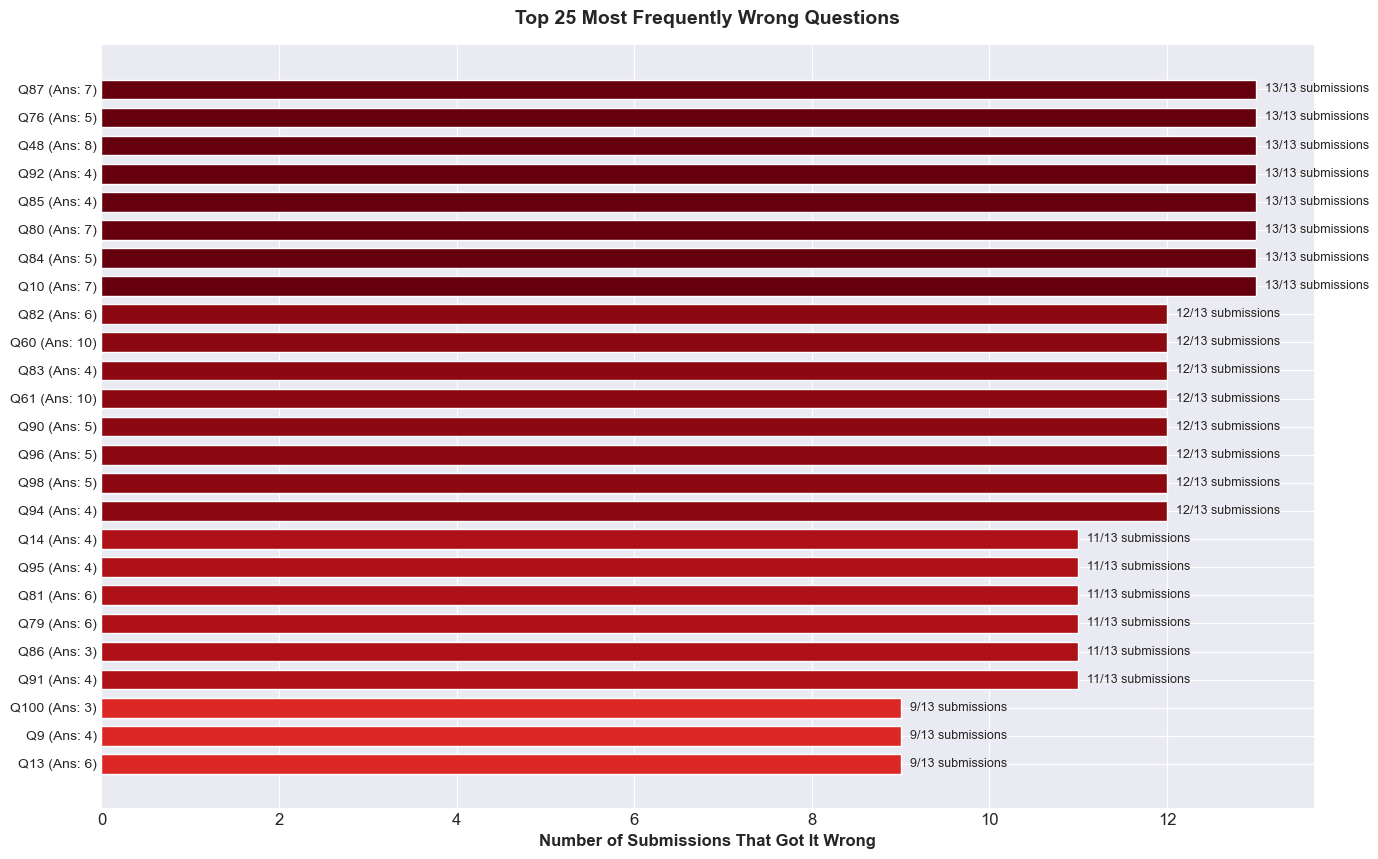

💾 Saved: ../visualizations/most_wrong_questions.png


In [8]:
# Count how many submissions got each question wrong
error_counts = (1 - error_matrix).sum(axis=1).astype(int)
error_counts = error_counts.sort_values(ascending=False)

# Filter: only questions that at least 1 submission got wrong
error_counts = error_counts[error_counts > 0]

print(f'📌 {len(error_counts)} questions were answered incorrectly by at least 1 submission\n')

# Show table
freq_df = pd.DataFrame({
    'Question ID': error_counts.index,
    'Times Wrong': error_counts.values,
    'Total Submissions': len(sub_files),
    'Correct Answer': [gold[gold['id'] == qid]['answer'].values[0] for qid in error_counts.index]
})
freq_df['Wrong Rate'] = (freq_df['Times Wrong'] / freq_df['Total Submissions'] * 100).round(1)
freq_df = freq_df.sort_values('Times Wrong', ascending=False).reset_index(drop=True)

display(
    freq_df.style
    .format({'Wrong Rate': '{:.1f}%'})
    .bar(subset=['Wrong Rate'], color='#F44336', vmin=0, vmax=100)
    .set_properties(**{'text-align': 'center'})
)

# Plot top wrong questions  
top_n = min(25, len(error_counts))
top_errors = error_counts.head(top_n)

fig, ax = plt.subplots(figsize=(14, max(6, top_n * 0.35)))
colors = plt.cm.Reds(top_errors.values / top_errors.max())
bars = ax.barh(
    range(len(top_errors)), 
    top_errors.values, 
    color=colors, 
    edgecolor='white',
    height=0.7
)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, top_errors.values)):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{count}/{len(sub_files)} submissions', va='center', fontsize=9)

ax.set_yticks(range(len(top_errors)))
ax.set_yticklabels([f'Q{q} (Ans: {gold[gold["id"]==q]["answer"].values[0]})' for q in top_errors.index], fontsize=10)
ax.set_xlabel('Number of Submissions That Got It Wrong', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Most Frequently Wrong Questions', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../visualizations/most_wrong_questions.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../visualizations/most_wrong_questions.png')

### 4.5 Per-Question Error Detail — What Each Submission Answered

In [9]:
# For the most frequently wrong questions, show what each submission answered
top_wrong_qids = freq_df.head(20)['Question ID'].values

for qid in top_wrong_qids:
    correct_ans = gold[gold['id'] == qid]['answer'].values[0]
    
    wrong_subs = []
    for csv_name in sub_files:
        errors = detailed_errors.get(csv_name, pd.DataFrame())
        if not errors.empty:
            q_error = errors[errors['Question ID'] == qid]
            if not q_error.empty:
                wrong_subs.append({
                    'Submission': csv_name.replace('.csv', ''),
                    'Submitted': q_error['Submitted Answer'].values[0],
                    'Correct': correct_ans
                })
    
    if wrong_subs:
        print(f'\n❌ Question {qid} (Correct Answer: {correct_ans})')
        print('-' * 50)
        detail_df = pd.DataFrame(wrong_subs)
        display(detail_df.style.set_properties(**{'text-align': 'center'}))
        print()


❌ Question 87 (Correct Answer: 7)
--------------------------------------------------


,Submission,Submitted,Correct
0,advanced_submission,2,7
1,sota_contextual_submission,1,7
2,ultimate_submission_2,2,7
3,typhoon_submission,2,7
4,baai_textsplitter,1,7
5,improved_advanced_submission,9,7
6,reflective_submission,1,7
7,loop_reasoning_submission,9,7
8,final_eval_pipeline,9,7
9,basic_loop_fast_submission,9,7




❌ Question 80 (Correct Answer: 7)
--------------------------------------------------


,Submission,Submitted,Correct
0,advanced_submission,1,7
1,sota_contextual_submission,1,7
2,ultimate_submission_2,1,7
3,typhoon_submission,1,7
4,baai_textsplitter,1,7
5,improved_advanced_submission,2,7
6,reflective_submission,9,7
7,loop_reasoning_submission,9,7
8,final_eval_pipeline,9,7
9,basic_loop_fast_submission,9,7




❌ Question 10 (Correct Answer: 7)
--------------------------------------------------


...

,Submission,Submitted,Correct
0,advanced_submission,1,4
1,sota_contextual_submission,1,4
2,baai_textsplitter,1,4
3,improved_advanced_submission,1,4
4,reflective_submission,9,4
5,loop_reasoning_submission,9,4
6,final_eval_pipeline,9,4
7,basic_loop_fast_submission,9,4
8,fast_loop_submission,9,4
9,submission_test,1,4




❌ Question 81 (Correct Answer: 6)
--------------------------------------------------


,Submission,Submitted,Correct
0,sota_contextual_submission,4,6
1,ultimate_submission_2,4,6
2,typhoon_submission,4,6
3,improved_advanced_submission,4,6
4,reflective_submission,1,6
5,loop_reasoning_submission,9,6
6,final_eval_pipeline,9,6
7,basic_loop_fast_submission,9,6
8,fast_loop_submission,9,6
9,submission_test,1,6




❌ Question 79 (Correct Answer: 6)
--------------------------------------------------


,Submission,Submitted,Correct
0,advanced_submission,5,6
1,sota_contextual_submission,5,6
2,ultimate_submission_2,5,6
3,typhoon_submission,5,6
4,baai_textsplitter,7,6
5,loop_reasoning_submission,9,6
6,final_eval_pipeline,9,6
7,basic_loop_fast_submission,9,6
8,fast_loop_submission,9,6
9,submission_test,1,6


### 4.6 Accuracy Distribution & Statistics

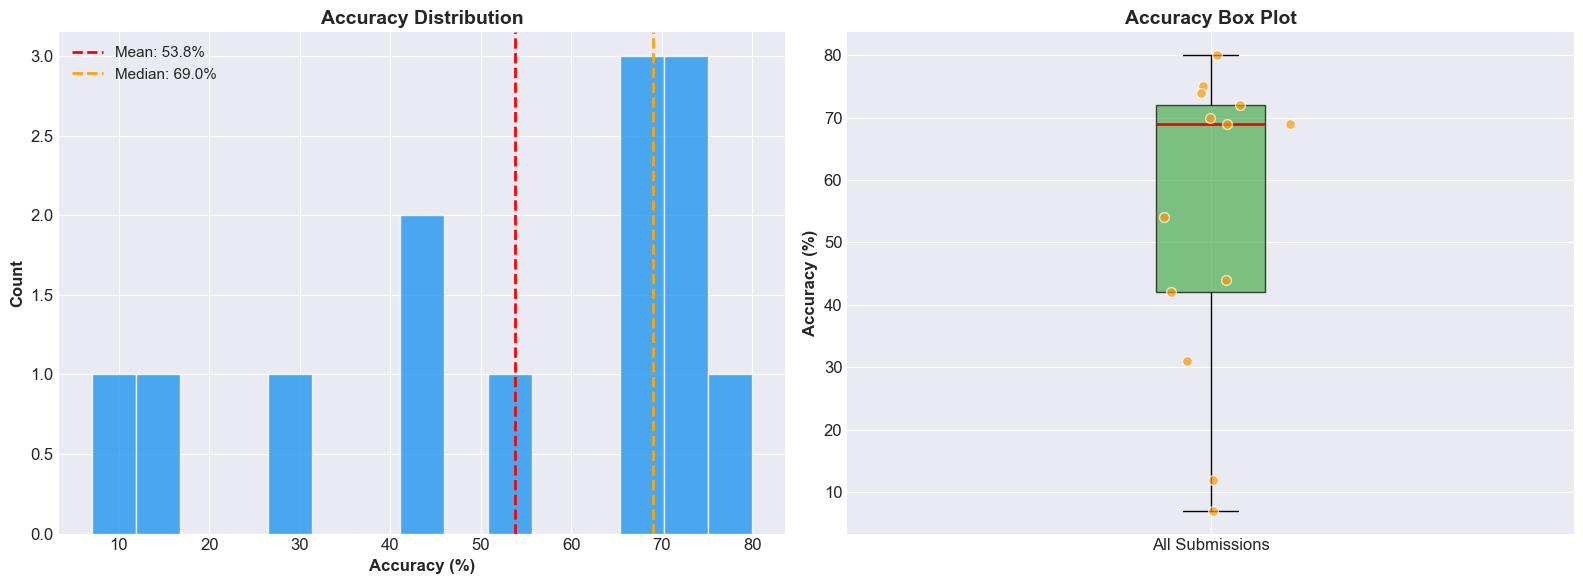


📈 Statistics:
  Mean Accuracy:   53.8%
  Median Accuracy: 69.0%
  Std Deviation:   24.7%
  Min Accuracy:    7.0% (pathumma_submission.csv)
  Max Accuracy:    80.0% (advanced_submission.csv)

💾 Saved: ../visualizations/accuracy_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1 = axes[0]
ax1.hist(summary_df['accuracy'], bins=15, color='#2196F3', edgecolor='white', alpha=0.8)
ax1.axvline(x=summary_df['accuracy'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {summary_df["accuracy"].mean():.1f}%')
ax1.axvline(x=summary_df['accuracy'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {summary_df["accuracy"].median():.1f}%')
ax1.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)

# Box plot
ax2 = axes[1]
bp = ax2.boxplot(summary_df['accuracy'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#4CAF50', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Box Plot', fontsize=14, fontweight='bold')
ax2.set_xticklabels(['All Submissions'])

# Add individual points
x_jitter = np.random.normal(1, 0.04, size=len(summary_df))
ax2.scatter(x_jitter, summary_df['accuracy'], alpha=0.7, color='#FF9800', s=50, zorder=5, edgecolor='white')

plt.tight_layout()
plt.savefig('../visualizations/accuracy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats summary
print('\n📈 Statistics:')
print(f'  Mean Accuracy:   {summary_df["accuracy"].mean():.1f}%')
print(f'  Median Accuracy: {summary_df["accuracy"].median():.1f}%')
print(f'  Std Deviation:   {summary_df["accuracy"].std():.1f}%')
print(f'  Min Accuracy:    {summary_df["accuracy"].min():.1f}% ({summary_df.loc[summary_df["accuracy"].idxmin(), "file"]})')
print(f'  Max Accuracy:    {summary_df["accuracy"].max():.1f}% ({summary_df.loc[summary_df["accuracy"].idxmax(), "file"]})')
print(f'\n💾 Saved: ../visualizations/accuracy_distribution.png')

### 4.7 Question Difficulty Grouped by Section

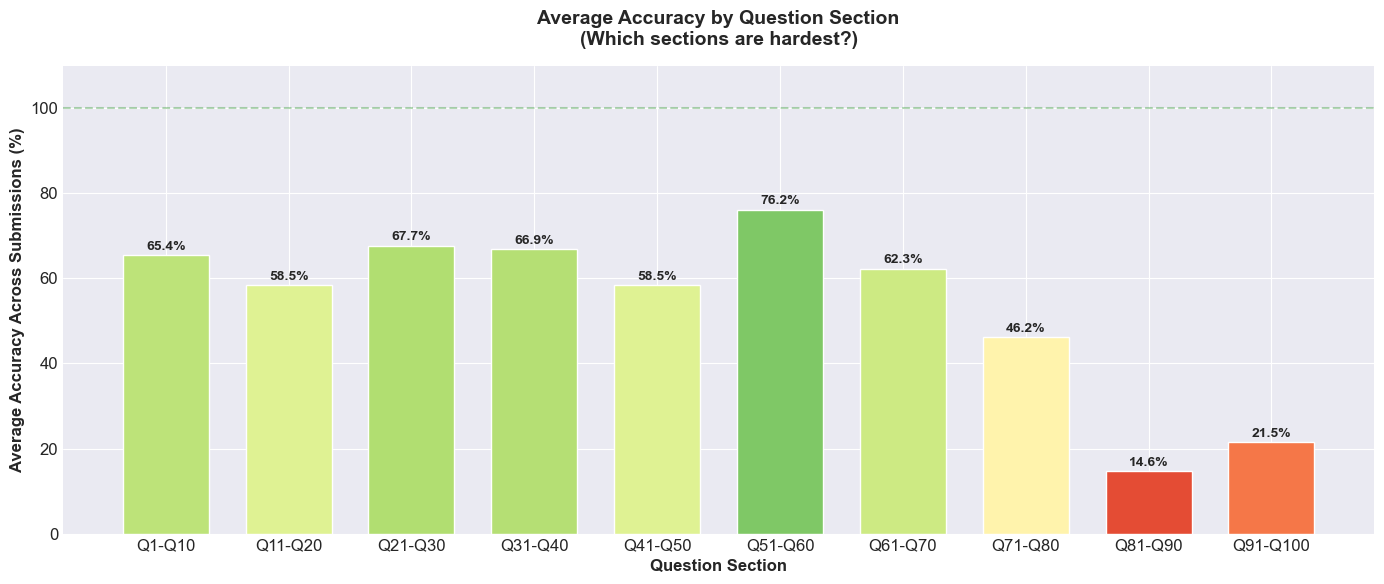

💾 Saved: ../visualizations/section_difficulty.png


In [11]:
# Group questions into sections of 10
section_accuracy = {}
for start in range(1, 101, 10):
    end = min(start + 9, 100)
    section_label = f'Q{start}-Q{end}'
    section_qids = list(range(start, end + 1))
    
    section_correct = error_matrix.loc[
        error_matrix.index.isin(section_qids)
    ].mean(axis=1).mean() * 100
    
    section_accuracy[section_label] = section_correct

fig, ax = plt.subplots(figsize=(14, 6))

sections = list(section_accuracy.keys())
acc_values = list(section_accuracy.values())
colors = plt.cm.RdYlGn([v/100 for v in acc_values])

bars = ax.bar(sections, acc_values, color=colors, edgecolor='white', width=0.7)

for bar, val in zip(bars, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Question Section', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Accuracy Across Submissions (%)', fontsize=12, fontweight='bold')
ax.set_title('Average Accuracy by Question Section\n(Which sections are hardest?)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.axhline(y=100, color='green', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/section_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../visualizations/section_difficulty.png')

## 5. Summary

In [ ]:
print('=' * 70)
print('📊 FINAL SUMMARY')
print('=' * 70)
print(f'\n🏆 Gold Standard: ai_studio_code.csv (Score: 1.0 on Kaggle)')
print(f'📁 Submissions compared: {len(summary_df)}')
print(f'\n--- Accuracy Ranking ---\n')
for i, row in summary_df.iterrows():
    medal = '🥇' if i == 1 else ('🥈' if i == 2 else ('🥉' if i == 3 else '  '))
    bar = '█' * int(row['accuracy'] / 5) + '░' * (20 - int(row['accuracy'] / 5))
    print(f'{medal} #{i:2d} | {bar} | {row["accuracy"]:5.1f}% | ✅{int(row["correct"]):3d} ❌{int(row["wrong"]):3d} | {row["file"]}')

# Hardest questions
print(f'\n--- Top 10 Hardest Questions ---\n')
for _, row in freq_df.head(10).iterrows():
    print(f'  Q{int(row["Question ID"]):3d} | Wrong by {int(row["Times Wrong"]):2d}/{int(row["Total Submissions"])} submissions ({row["Wrong Rate"]}%) | Correct Answer: {int(row["Correct Answer"])}')

print(f'\n📊 Average accuracy across all submissions: {summary_df["accuracy"].mean():.1f}%')
print('=' * 70)

📊 FINAL SUMMARY

🏆 Gold Standard: ai_studio_code.csv (Score: 1.0 on Kaggle)
📁 Submissions compared: 13

--- Accuracy Ranking ---

🥇 # 1 | ████████████████░░░░ |  80.0% | ✅ 80 ❌ 20 | advanced_submission.csv
🥈 # 2 | ███████████████░░░░░ |  75.0% | ✅ 75 ❌ 25 | sota_contextual_submission.csv
🥉 # 3 | ██████████████░░░░░░ |  74.0% | ✅ 74 ❌ 26 | ultimate_submission_2.csv
   # 4 | ██████████████░░░░░░ |  72.0% | ✅ 72 ❌ 28 | typhoon_submission.csv
   # 5 | ██████████████░░░░░░ |  70.0% | ✅ 70 ❌ 30 | baai_textsplitter.csv
   # 6 | █████████████░░░░░░░ |  69.0% | ✅ 69 ❌ 31 | improved_advanced_submission.csv
   # 7 | █████████████░░░░░░░ |  69.0% | ✅ 69 ❌ 31 | reflective_submission.csv
   # 8 | ██████████░░░░░░░░░░ |  54.0% | ✅ 54 ❌ 46 | loop_reasoning_submission.csv
   # 9 | ████████░░░░░░░░░░░░ |  44.0% | ✅ 44 ❌ 56 | final_eval_pipeline.csv
   #10 | ████████░░░░░░░░░░░░ |  42.0% | ✅ 42 ❌ 58 | basic_loop_fast_submission.csv
   #11 | ██████░░░░░░░░░░░░░░ |  31.0% | ✅ 31 ❌ 69 | fast_loop_submission

Bad pipe message: %s [b"\x08\xf7\xcc\x0fz\x95f7\xa0|x\xa1\xa7\xdf\xeb`y' v5\xc0{7g\xed3\xad8\xf8l:lvl\xde\r\xa9\x91d`\xc8z\xe0\xf2\xa7A\xbb$\x8bI\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00\x06\x00\x1d\x00\x17\x00\x18\x00\x0b\x00\x02\x01\x00\x00#\x00\x00\x00\r\x00\x14\x00\x12\x04\x03\x08\x04\x04\x01\x05\x03\x08\x05\x05\x01\x08\x06\x06", b'']
Bad pipe message: %s [b'']
Bad pipe message: %s [b'&\x00$\x00\x1d\x00 >R\xf7\xb4\xfa\xc1\xda\xb6jx\x03\x16\x08\xb1\xbe\x94\x8d\xdb\x07\x1f>x\xc5#VHH\xf0\xcd6\r \x00-\x00\x02\x01\x01\x00+\x00\x05\x04']
Bad pipe message: %s [b'\x03\x03']
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/ai_env/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/homebre